
# 第5章 机器学习基础

## 5.1 泛化：机器学习的目标

机器学习的根本问题在优化与泛化之间的矛盾。

- **优化**（optimization）是指调节模型使其在训练数据上得到最佳性能的过程

- **泛化**（generalization）则是指训练好的模型在前所未见的数据上的性能。

### 5.1.1 欠拟合与过拟合

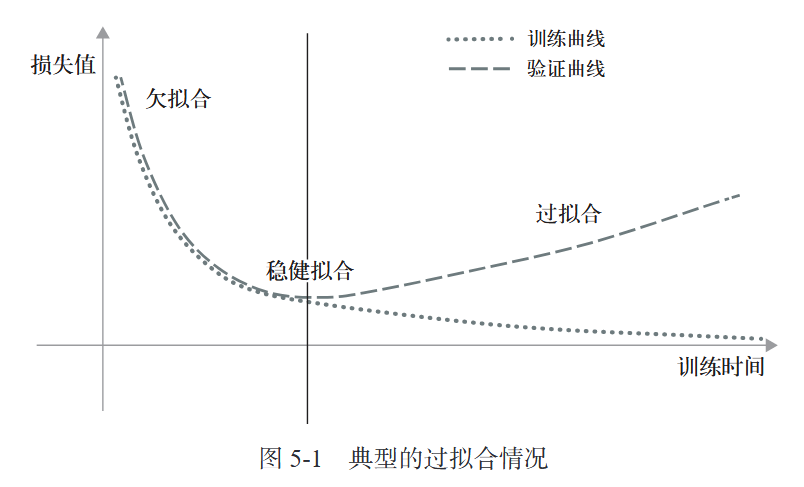

训练开始时,优化和泛化是相关的:训练数据上的损失越小,测试数据上的损失也越小。这时,模型是**欠拟合**(underfit)的,即仍有改进的空间,模型还没有对训练数据中的所有相关模式建模。但在训练数据上迭代一定次数之后,泛化能力就不再提高,验证指标先是不变,然后开始变差。这时模型开始**过拟合**,它开始学习仅和训练数据有关的模式,但对新数据而言,这些模式是错误的或是不相关的。

如果数据的不确定性很大或者包含罕见的特征,那么就特别容易出现过拟合。我们来看几  个具体的例子。


#### 1. 嘈杂的训练数据

奇怪的数据或者标签错误的数据都会使得模型出现过拟合的现象。

#### 2. 模糊特征

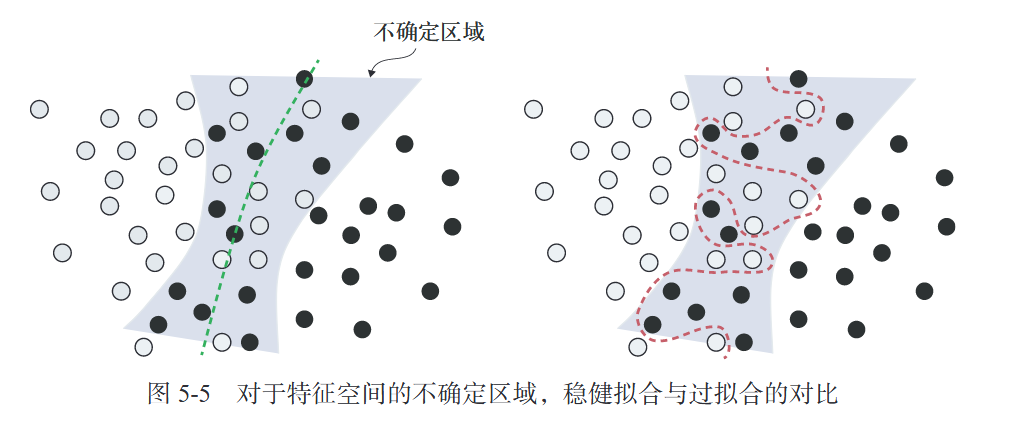

一些特征值标签没有明确的分界线，比如：味道（好吃、一般、难吃）、人品（好、普通、坏）。而且在人为标注的时候也会因为标注者的不同导致判断标准不一样。


#### 3. 罕见特征与虚假特征的相关性

如果你一生中只见过两只橙色的虎斑猫,而且它们碰巧都非常不合群,那么你可能会得出  这样的结论:橙色的虎斑猫通常不合群。这就是过拟合。

重要的是,一个特征值出现次数较多,也会导致虚假的相关性。假设一个单词出现在训练  数据的 100 个样本中,其中 54% 与正面情绪相关,46% 与负面情绪相关。这种差异很可能完全  是统计上的偶然情况,但你的模型很可能学会利用这个特征来完成分类任务。这是过拟合最常  见的来源之一。

一个例子，对于 MNIST 数据集,将 784 个**白噪声通道**连接到现有的 784  个数据维度中,从而创建一个新的训练集：

代码清单 5-1 向 MNIST 数据集添加白噪声通道或全零通道

In [2]:
from tensorflow.keras.datasets import mnist
import numpy as np

(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype('float32') / 255

train_images_with_noise_channels = np.concatenate(
    [train_images, np.random.random((len(train_images), 784))], axis=1
)

train_images_with_zeros_channels = np.concatenate(
    [train_images, np.zeros((len(train_images), 784))], axis=1
)

2025-02-14 13:35:24.291165: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudart.so.10.1


代码清单 5-2 对于带有噪声通道或全零通道的 MNIST 数据，训练相同的模型

In [3]:
from tensorflow import keras
from tensorflow.keras import layers

def get_model():
    model = keras.Sequential([
        layers.Dense(512, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='rmsprop',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model = get_model()
history_noise = model.fit(
    train_images_with_noise_channels, train_labels,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)

model = get_model()
history_zeros = model.fit(
    train_images_with_zeros_channels, train_labels,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)

2025-02-14 13:35:26.913342: I tensorflow/compiler/jit/xla_cpu_device.cc:41] Not creating XLA devices, tf_xla_enable_xla_devices not set
2025-02-14 13:35:26.919178: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcuda.so.1
2025-02-14 13:35:26.976795: E tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:927] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-02-14 13:35:26.976866: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1720] Found device 0 with properties: 
pciBusID: 0000:01:00.0 name: NVIDIA GeForce RTX 3060 Laptop GPU computeCapability: 8.6
coreClock: 1.425GHz coreCount: 30 deviceMemorySize: 6.00GiB deviceMemoryBandwidth: 312.97GiB/s
2025-02-14 13:35:26.976889: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudart.so.10.1
2025-02-14 13:35:27.003639: I tensorflow/stream_exec

Epoch 1/10


2025-02-14 13:35:30.197559: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcublas.so.10


375/375 [==============================] - 3s 6ms/step - loss: 1.0619 - accuracy: 0.7029 - val_loss: 0.2747 - val_accuracy: 0.9170
Epoch 2/10
375/375 [==============================] - 2s 5ms/step - loss: 0.2704 - accuracy: 0.9137 - val_loss: 0.1889 - val_accuracy: 0.9439
Epoch 3/10
375/375 [==============================] - 2s 5ms/step - loss: 0.1669 - accuracy: 0.9487 - val_loss: 0.1691 - val_accuracy: 0.9482
Epoch 4/10
375/375 [==============================] - 2s 6ms/step - loss: 0.1115 - accuracy: 0.9650 - val_loss: 0.1715 - val_accuracy: 0.9477
Epoch 5/10
375/375 [==============================] - 2s 6ms/step - loss: 0.0836 - accuracy: 0.9752 - val_loss: 0.1291 - val_accuracy: 0.9641
Epoch 6/10
375/375 [==============================] - 2s 6ms/step - loss: 0.0587 - accuracy: 0.9814 - val_loss: 0.1326 - val_accuracy: 0.9613
Epoch 7/10
375/375 [==============================] - 2s 6ms/step - loss: 0.0436 - accuracy: 0.9860 - val_loss: 0.1215 - val_accuracy: 0.9672
Epoch 8/10
375/37

代码清单 5-3 绘图比较验证精度

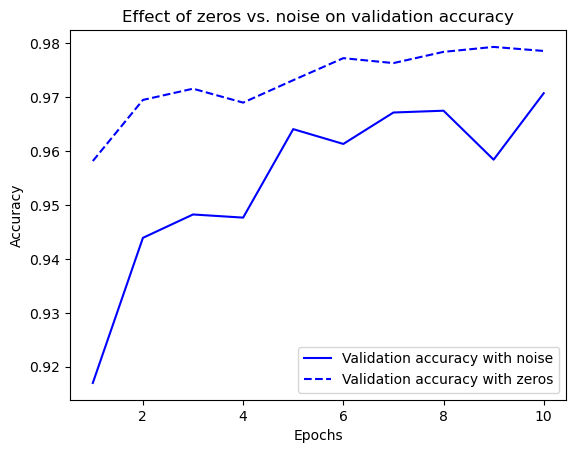

In [4]:
import matplotlib.pyplot as plt

val_acc_noise = history_noise.history['val_accuracy']
val_acc_zeros = history_zeros.history['val_accuracy']

epochs = range(1, 11)
plt.plot(epochs, val_acc_noise, 'b-',
         label='Validation accuracy with noise')
plt.plot(epochs, val_acc_zeros, 'b--',
         label='Validation accuracy with zeros')
plt.title('Effect of zeros vs. noise on validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

噪声特征不可避免会导致过拟合。因此,如果你不确定特征究竟是有用的还是无关紧要的, 那么常见的做法是在训练前进行**特征选择**(feature selection)。例如,将 IMDB 数据限制为前 10 000 个最常出现的单词,就是一种粗略的特征选择。特征选择的常用方法是对每个特征计算有用性分数,并且只保留那些分数高于某个阈值的特征。**有用性分数**(usefulness score)是用于衡量特征对于任务来说所包含信息量大小的指标,比如特征与标签之间的互信息。这么做可以过滤前面例子中的白噪声通道。



### 5.1.2 深度学习泛化的本质

关于深度学习模型的一个值得注意的事实是，只要模型具有足够的表示能力，就可以训练模型拟合任何数据，包括虚假的数据。这说明机器学习具有很强的泛化能力。

代码清单 5-4 将标签随机打乱，拟合一个 MNIST 模型

In [5]:
(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype('float32') / 255

random_train_labels = train_labels[:]
np.random.shuffle(random_train_labels)

model = keras.Sequential([
    layers.Dense(512, activation='relu'),
    layers.Dense(10, activation='softmax')
])
model.compile(optimizer='rmsprop',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.fit(train_images, random_train_labels, epochs=10, batch_size=128, validation_split=0.2)

(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype('float32') / 255

model = keras.Sequential([
    layers.Dense(512, activation='relu'),
    layers.Dense(10, activation='softmax')
])
model.compile(optimizer='rmsprop',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.fit(train_images, train_labels, epochs=10, batch_size=128, validation_split=0.2)

(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype('float32') / 255

random_train_labels = train_labels[:]
np.random.shuffle(random_train_labels)

model = keras.Sequential([
    layers.Dense(512, activation='relu'),
    layers.Dense(10, activation='softmax')
])
model.compile(optimizer='rmsprop',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.fit(train_images, random_train_labels,
          epochs=100,
          batch_size=128,
          validation_split=0.2)

Epoch 1/10
375/375 [==============================] - 2s 6ms/step - loss: 2.3413 - accuracy: 0.1025 - val_loss: 2.3073 - val_accuracy: 0.1070
Epoch 2/10
375/375 [==============================] - 2s 5ms/step - loss: 2.2986 - accuracy: 0.1203 - val_loss: 2.3142 - val_accuracy: 0.1039
Epoch 3/10
375/375 [==============================] - 2s 5ms/step - loss: 2.2875 - accuracy: 0.1331 - val_loss: 2.3250 - val_accuracy: 0.0999
Epoch 4/10
375/375 [==============================] - 2s 5ms/step - loss: 2.2721 - accuracy: 0.1439 - val_loss: 2.3248 - val_accuracy: 0.0990
Epoch 5/10
375/375 [==============================] - 2s 5ms/step - loss: 2.2547 - accuracy: 0.1594 - val_loss: 2.3399 - val_accuracy: 0.0993
Epoch 6/10
375/375 [==============================] - 2s 5ms/step - loss: 2.2333 - accuracy: 0.1727 - val_loss: 2.3542 - val_accuracy: 0.0989
Epoch 7/10
375/375 [==============================] - 2s 5ms/step - loss: 2.2061 - accuracy: 0.1897 - val_loss: 2.3648 - val_accuracy: 0.1006
Epoch 

深度学习泛化的本质于深度学习模型本身关系不大，而与现实世界中的信息结构密切相关。下面是具体解释：

#### 1. 流形假说

按着 MNIST 的数据结构，会有 $256^(28*28)$ 种可能的数据（**父空间**），这笔宇宙种的原子数还大，但是能够表示手写数字的数据（图片）仅占很小的部分（**子空间**）。而子空间内的数据并不是随机散布的，而是**连续**的：如果取一个样本并稍加修改，那么它仍然可以被识别为同一个手写数字。其次，有效子空间中的所有样本都由穿过子空间的光滑路径**连接**（欧几里得空间），数组的可能性空间中构成了一个**流形**(manifold)

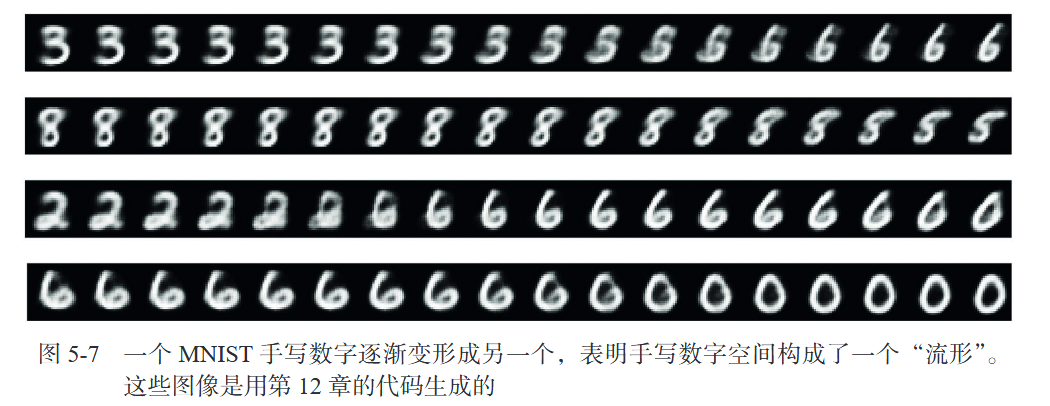

流行假说意味着：

- 机器学习模型只需要在其输入空间中拟合相对简单、低维、高度结构化的子空间

- 在其中一个流形中，总是可以在两个输入之间进行**插值**（interpolate）

#### 2. 插值作为泛化的来源

#### 3. 深度学习为何有效

#### 4. 训练数据至关重要

只有数据形成一个可以插值的流形，模型才能够泛化。特征包含的信息量越大、特征噪声越小，泛化能力就越强，因为输入空间更简单，结构也更合理。数据管理和特征工程对于泛化至关重要。

由于深度学习是曲线拟合，因此为了使模型表现良好，需要在输入空间的**密集采样**上训练模型。这里的“密集采样”是指训练数据应该密集地覆盖整个输入数据流形。

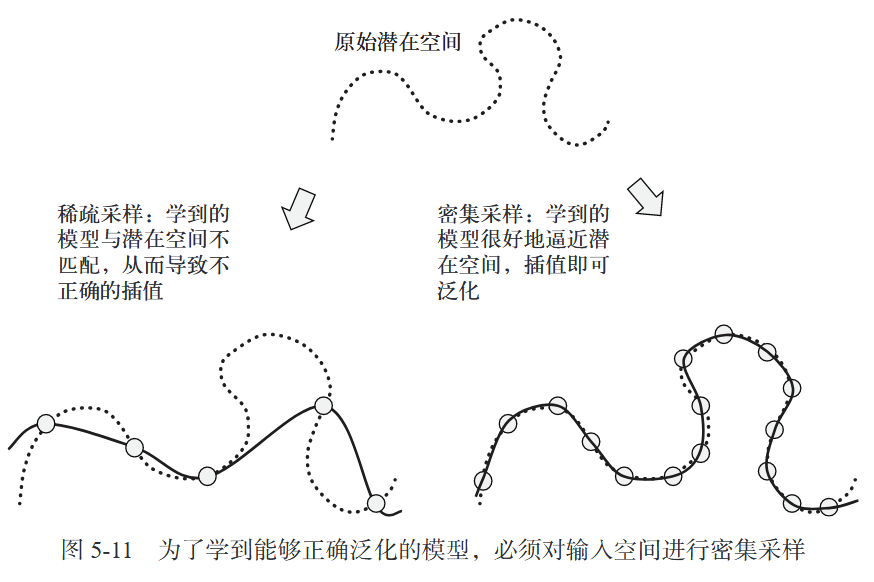

如果无法获取更多数据，次优解决方法是调节模型允许存储的信息量，或者对模型曲线的平滑度添加约束。如果一个神经网络只能记住几种模式或非常有规律的模式,那么优化过程将  迫使模型专注于最显著的模式,从而更可能得到良好的泛化。这种降低过拟合的方法叫作**正则化**(regularization)

## 5.2 评估机器学习模型

### 5.2.1 训练集、验证集和测试集

开发模型时总是需要调节模型配置，比如确定层数或每层大小[ 这些叫作模型的**超参数**(hyperparameter),以便与**参数**(权重)区分开 ]。这个调节过程需要使用模型在验证数据上的表现作为反馈信号。

模型一定不能读取与测试集有关的任何信息,间接读取也不行。

如果可用数据很少，这里有三种经典的评估方法：简单的留出验证、$K$ 折交叉验证，以及待遇打乱数据的重复 $k$ 折交叉验证。

#### 1. 简单的留出验证

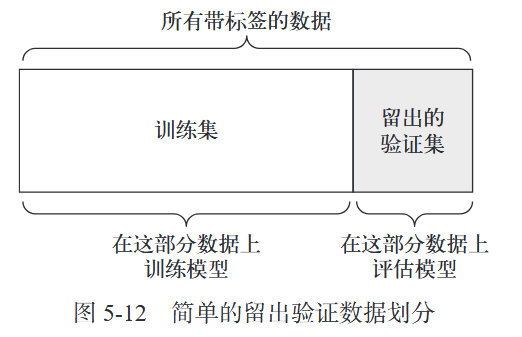

代码清单 5-5 留出验证（注意，为简单起见省略了标签）

In [ ]:
data = ""
num_validation_samples = 10000
np.random.shuffle(data)
validation_data = data[:num_validation_samples]
training_data = data[num_validation_samples:]
model = get_model()
model.fit(training_data, ...)
validation_score = model.evaluate(validation_data, ...)

# 对模型进行调节、重新训练、评估，然后再次调节

# 调节好模型参数之后，通常的做法是在所有非测试数据上从头开始训练最终模型
model = get_model()
model.fit(np.concatenate([training_data, validation_data]), ...)

test_score = model.evaluate(test_data, ...)


#### 2. $K$ 折交叉验证

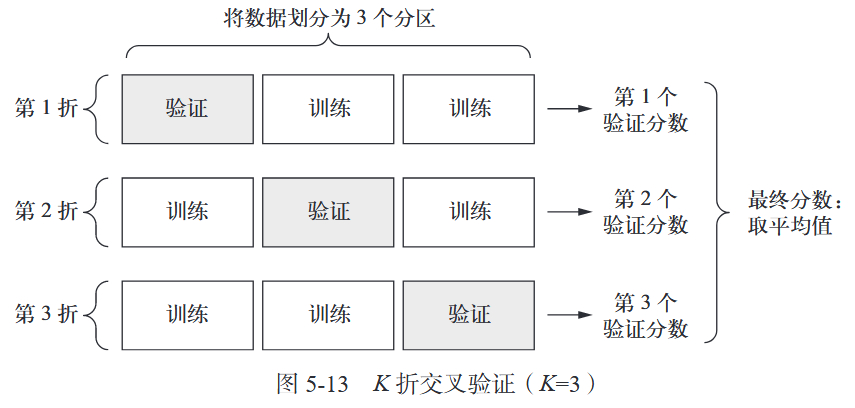

代码清单 5-6 $K$ 折交叉验证（注意，为了简单起见省略了标签）

In [ ]:
k = 3
num_validation_samples = len(data) // k
np.random.shuffle(data)
validation_scores = []
for fold in range(k):
    validation_data = data[num_validation_samples * fold:
                           num_validation_samples * (fold + 1)]
    training_data = data[:num_validation_samples * fold] + data[num_validation_samples * (fold + 1):]
    model = get_model()
    model.fit(training_data, ...)
    validation_score = model.evaluate(validation_data, ...)
    validation_scores.append(validation_score)
validation_score = np.average(validation_scores)

# 对模型进行调节、重新训练、评估，然后再次调节

# 调节好模型参数之后，通常的做法是在所有非测试数据上从头开始训练最终模型
model = get_model()
model.fit(data, ...)
test_score = model.evaluate(test_data, ...)


#### 3. 带有打乱数据的重复 $K$ 折交叉验证

如果可用的数据相对较少，而你又需要尽可能精确地评估模型，那么可以使用带有打乱数据的重复 K 折交叉验证。我发现这种方法在 Kaggle 竞赛中特别有用。具体做法是多次使用 K 折交叉验证，每次将数据划分为 K 个分区之前都将数据打乱。

### 5.2.2 超越基于常识的基准

在面对一个全新的问题时,你需要设定一个可以参考的基于常识的基准,这很重要。

### 5.2.3 模型评估的注意事项

选择模型评估方法时，需要注意一下几点。

- **数据代表性**（data representativeness）

- **时间箭头**（the arrow of time）:如果要根据过去预测未来，那么要保证测试集的数据要晚于训练集，而不应该随机打乱数据。

- **时间冗余**（redundancy in your data）：有些数据点会出现两次，虽然这在现实生活中常见，但是在训练过程中，一定要确保训训练集和测试集之间没有交集。

## 5.3 改进模型拟合

再一开始就创建一个过拟合的模型，之后再通过降低过拟合来提高泛化能力。在获得过拟合模型的过程中最常见的 3 种问题：

- 训练不开始：训练损失不随着时间的推移而减小

- 训练开始得很好，但模型没有真正泛化：模型无法超越基于常识的基准

- 训练损失和验证损失都随着时间的推移而减小，模型可以超越基准，但似乎无法过拟合，这表示模型仍处于欠拟合状态

### 5.3.1 调节关键的梯度下降参数

有时训练不开始，或者过早停止。保持其他参数不变，调节学习率和批量大小通常就足够了

代码清单 5-7 使用过大的学习率训练 MNIST 模型

In [10]:
(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])
model.compile(optimizer=keras.optimizers.RMSprop(1.), # 1e-2 就是学习率
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
model.fit(train_images, train_labels,
          epochs=10,
          batch_size=128,
          validation_split=0.2)

Epoch 1/10
375/375 [==============================] - 3s 7ms/step - loss: 3528.7192 - accuracy: 0.4434 - val_loss: 3.2566 - val_accuracy: 0.2530
Epoch 2/10
375/375 [==============================] - 2s 6ms/step - loss: 6.3784 - accuracy: 0.2232 - val_loss: 3.1175 - val_accuracy: 0.2117
Epoch 3/10
375/375 [==============================] - 2s 6ms/step - loss: 3.4319 - accuracy: 0.2234 - val_loss: 2.0667 - val_accuracy: 0.2553
Epoch 4/10
375/375 [==============================] - 2s 6ms/step - loss: 3.0754 - accuracy: 0.2530 - val_loss: 2.1471 - val_accuracy: 0.2713
Epoch 5/10
375/375 [==============================] - 2s 6ms/step - loss: 3.1624 - accuracy: 0.2809 - val_loss: 2.3530 - val_accuracy: 0.2578
Epoch 6/10
375/375 [==============================] - 2s 6ms/step - loss: 2.7573 - accuracy: 0.2683 - val_loss: 2.1724 - val_accuracy: 0.2177
Epoch 7/10
375/375 [==============================] - 2s 6ms/step - loss: 2.3789 - accuracy: 0.2734 - val_loss: 2.6079 - val_accuracy: 0.2672
Epo

这个模型的训练精度和验证精度很快就达到了 30% ~ 40%，但无法超出这个范围。下面我们试着把学习率降低到一个更合理的值 1e-2。

代码清单 5-8 使用更合理的学习率训练同一个模型

In [11]:
model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])
model.compile(optimizer=keras.optimizers.RMSprop(1e-2), # 1e-2 就是学习率
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
model.fit(train_images, train_labels,
          epochs=10,
          batch_size=128,
          validation_split=0.2)

Epoch 1/10
375/375 [==============================] - 3s 7ms/step - loss: 0.8347 - accuracy: 0.8338 - val_loss: 0.1226 - val_accuracy: 0.9632
Epoch 2/10
375/375 [==============================] - 2s 6ms/step - loss: 0.1424 - accuracy: 0.9616 - val_loss: 0.1594 - val_accuracy: 0.9647
Epoch 3/10
375/375 [==============================] - 2s 6ms/step - loss: 0.1068 - accuracy: 0.9741 - val_loss: 0.1735 - val_accuracy: 0.9682
Epoch 4/10
375/375 [==============================] - 3s 7ms/step - loss: 0.0897 - accuracy: 0.9788 - val_loss: 0.1749 - val_accuracy: 0.9708
Epoch 5/10
375/375 [==============================] - 2s 6ms/step - loss: 0.0743 - accuracy: 0.9840 - val_loss: 0.1806 - val_accuracy: 0.9753
Epoch 6/10
375/375 [==============================] - 2s 6ms/step - loss: 0.0697 - accuracy: 0.9856 - val_loss: 0.2820 - val_accuracy: 0.9653
Epoch 7/10
375/375 [==============================] - 2s 6ms/step - loss: 0.0643 - accuracy: 0.9875 - val_loss: 0.2445 - val_accuracy: 0.9748
Epoch 

如果遇到类似问题，可以尝试降低或提高学习率、增加批量大小。

### 5.3.2 利用更好的架构预设

模型的验证指标没有提高，可能是方法从根本上就是错误的：

- 数据没有包含足够的信息来预测目标

- 模型类型可能不适合解决当前问题

### 5.3.3 提高模型容量

代码清单 5-9 在 MNIST 上训练的一个简单的 logistic 回归模型

Epoch 1/20
375/375 [==============================] - 2s 5ms/step - loss: 1.0399 - accuracy: 0.7327 - val_loss: 0.3583 - val_accuracy: 0.9063
Epoch 2/20
375/375 [==============================] - 2s 5ms/step - loss: 0.3657 - accuracy: 0.9004 - val_loss: 0.3069 - val_accuracy: 0.9154
Epoch 3/20
375/375 [==============================] - 2s 5ms/step - loss: 0.3189 - accuracy: 0.9118 - val_loss: 0.2919 - val_accuracy: 0.9185
Epoch 4/20
375/375 [==============================] - 2s 5ms/step - loss: 0.2983 - accuracy: 0.9177 - val_loss: 0.2831 - val_accuracy: 0.9214
Epoch 5/20
375/375 [==============================] - 2s 5ms/step - loss: 0.2897 - accuracy: 0.9190 - val_loss: 0.2767 - val_accuracy: 0.9233
Epoch 6/20
375/375 [==============================] - 2s 5ms/step - loss: 0.2853 - accuracy: 0.9202 - val_loss: 0.2733 - val_accuracy: 0.9262
Epoch 7/20
375/375 [==============================] - 2s 4ms/step - loss: 0.2756 - accuracy: 0.9230 - val_loss: 0.2688 - val_accuracy: 0.9253
Epoch 

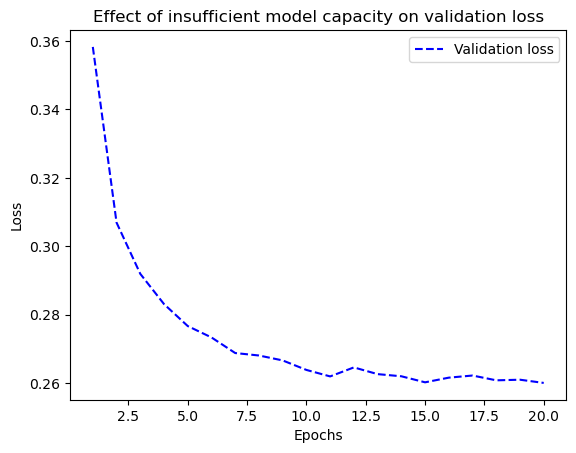

In [13]:
model = keras.Sequential([layers.Dense(10, activation="softmax")])
model.compile(optimizer="rmsprop",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
history_small_model = model.fit(
    train_images, train_labels,
    epochs=20,
    batch_size=128,
    validation_split=0.2
)

import matplotlib.pyplot as plt
val_loss = history_small_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(epochs, val_loss, "b--",
         label = "Validation loss")
plt.title("Effect of insufficient model capacity on validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

上面这个模型的损失值达到 0.26 之后就保持不变了，无法实现过拟合。这种情况可能是因为模型的**表示能力**（representational power）存在问题，可以设计一个**容量**（capacity）更大的模型，可以通过添加更多的层、使用更多参数的层，或者使用合适的层类型。

其实，在任何情况下都可以实现过拟合。

Epoch 1/20
375/375 [==============================] - 3s 7ms/step - loss: 0.5982 - accuracy: 0.8325 - val_loss: 0.1964 - val_accuracy: 0.9428
Epoch 2/20
375/375 [==============================] - 3s 7ms/step - loss: 0.1691 - accuracy: 0.9513 - val_loss: 0.1331 - val_accuracy: 0.9617
Epoch 3/20
375/375 [==============================] - 3s 8ms/step - loss: 0.1114 - accuracy: 0.9665 - val_loss: 0.1101 - val_accuracy: 0.9689
Epoch 4/20
375/375 [==============================] - 3s 8ms/step - loss: 0.0860 - accuracy: 0.9734 - val_loss: 0.1065 - val_accuracy: 0.9688
Epoch 5/20
375/375 [==============================] - 3s 7ms/step - loss: 0.0690 - accuracy: 0.9792 - val_loss: 0.1008 - val_accuracy: 0.9722
Epoch 6/20
375/375 [==============================] - 3s 7ms/step - loss: 0.0533 - accuracy: 0.9838 - val_loss: 0.0951 - val_accuracy: 0.9731
Epoch 7/20
375/375 [==============================] - 3s 7ms/step - loss: 0.0450 - accuracy: 0.9867 - val_loss: 0.1154 - val_accuracy: 0.9685
Epoch 

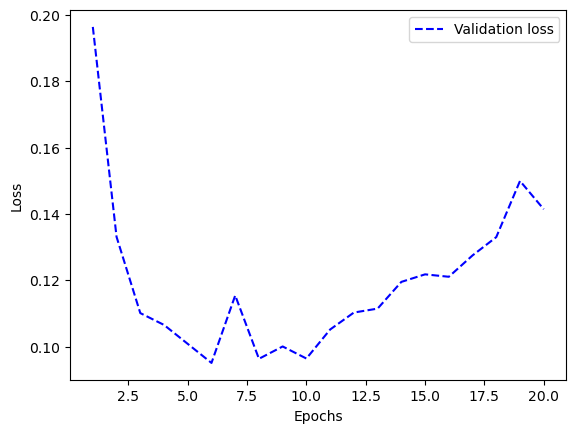

In [14]:
# 接下来用上面的数据训练一个`容量`更大的模型

model = keras.Sequential([
    layers.Dense(96, activation="relu"),
    layers.Dense(96, activation="relu"),
    layers.Dense(10, activation="softmax")
])
model.compile(optimizer="rmsprop",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
history_large_model = model.fit(
    train_images, train_labels,
    epochs=20,
    batch_size=128,
    validation_split=0.2
)
val_larg_loss = history_large_model.history["val_loss"]
plt.plot(range(1, 21), val_larg_loss, "b--", label="Validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

这个曲线才应该是正确的：模型很快拟合，并在 8 轮之后开始过拟合。

## 5.4 提高泛化能力

### 5.4.1 数据集管理

- 确保拥有足够的数据（密集采样）。

- 尽量减少标签错误。

- 清理数据并处理缺失值。

- 如果有很多特征，在不确定哪些特征有用的情况下，需要进行特征选择。

### 5.4.2 特征工程

**特征工程**是指将数据输入模型之前，利用你自己关于数据和机器学习算法的知识对数据进行硬编码的变换，以改善算法的效果。

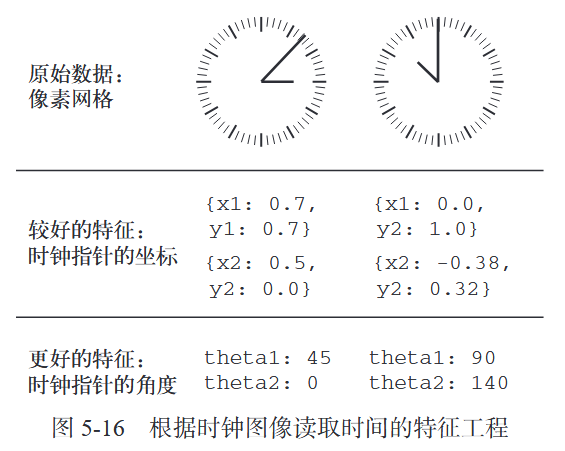

特征工程的本质：用更简单的方式表述问题，从而使问题更容易解决。特征工程可以让潜在流形变得更平滑、更简单、更有条理。

> 在深度学习出现之前，特征工程曾经是机器学习工作流程中最重要的部分，因为经典的浅层算法没有足够丰富的假设空间来自主学习有用的表示。

- 良好的特征有助于更优雅地解决问题，同时使用更少的资源。

- 良好的特征可以用更少的数据解决问题。


### 5.4.3 提前终止

在 Keras 中，我们通常使用 EarlyStopping 回调函数来实现这一点，它会在验证指标停止改善时立即中断训练，同时记录最佳模型状态。

### 5.4.4 模型正则化

正则化方法是一组最佳实践，可以主动降低模型完美拟合训练数据的能力，其目的是提高模型的验证性能。

模型正则化过程应该始终由一个准确的评估方法来引导。只有能够衡量泛化，才能实现泛化。

需要在**容量过大**和**容量不足**之间找到一个平衡点。

但是目前没有一个数学功能能够确定最佳层数或每层的最佳大小。要确定合适的模型规模，一般的工作流程是开始时选择相对较少的层和参数，然后逐渐增加层的大小或添加新层，直到这种增加对验证损失的影响变得很小。

代码清单 5-10 初始模型

In [35]:
from tensorflow.keras.datasets import imdb
(train_data, train_labels), _ = imdb.load_data(num_words=10000)

def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.
    return results
train_data = vectorize_sequences(train_data)

model = keras.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])
history_original = model.fit(train_data, train_labels,
                             epochs=20, batch_size=512, validation_split=0.4)

<__array_function__ internals>:180: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
/home/caoqiuyu/miniconda3/envs/tf-gpu/lib/python3.9/site-packages/tensorflow/python/keras/datasets/imdb.py:159: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  x_train, y_train = np.array(xs[:idx]), np.array(labels[:idx])
/home/caoqiuyu/miniconda3/envs/tf-gpu/lib/python3.9/site-packages/tensorflow/python/keras/datasets/imdb.py:160: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with differ

Epoch 1/20
30/30 [==============================] - 2s 52ms/step - loss: 0.5819 - accuracy: 0.7119 - val_loss: 0.3984 - val_accuracy: 0.8496
Epoch 2/20
30/30 [==============================] - 1s 26ms/step - loss: 0.3240 - accuracy: 0.8980 - val_loss: 0.3061 - val_accuracy: 0.8858
Epoch 3/20
30/30 [==============================] - 1s 26ms/step - loss: 0.2307 - accuracy: 0.9246 - val_loss: 0.2801 - val_accuracy: 0.8899
Epoch 4/20
30/30 [==============================] - 1s 24ms/step - loss: 0.1716 - accuracy: 0.9445 - val_loss: 0.2802 - val_accuracy: 0.8893
Epoch 5/20
30/30 [==============================] - 1s 28ms/step - loss: 0.1373 - accuracy: 0.9587 - val_loss: 0.2837 - val_accuracy: 0.8899
Epoch 6/20
30/30 [==============================] - 1s 25ms/step - loss: 0.1120 - accuracy: 0.9680 - val_loss: 0.2952 - val_accuracy: 0.8874
Epoch 7/20
30/30 [==============================] - 1s 27ms/step - loss: 0.0921 - accuracy: 0.9751 - val_loss: 0.3240 - val_accuracy: 0.8817
Epoch 8/20
30

代码清单 5-11 容量更小的模型

In [22]:
model = keras.Sequential([
    layers.Dense(4, activation="relu"),
    layers.Dense(4, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])
history_smaller_model = model.fit(
    train_data, train_labels,
    epochs=20, batch_size=512, validation_split=0.4
)

Epoch 1/20
30/30 [==============================] - 2s 51ms/step - loss: 0.6555 - accuracy: 0.5990 - val_loss: 0.5822 - val_accuracy: 0.7294
Epoch 2/20
30/30 [==============================] - 1s 25ms/step - loss: 0.5633 - accuracy: 0.7683 - val_loss: 0.5398 - val_accuracy: 0.7492
Epoch 3/20
30/30 [==============================] - 1s 24ms/step - loss: 0.5049 - accuracy: 0.8322 - val_loss: 0.5046 - val_accuracy: 0.8090
Epoch 4/20
30/30 [==============================] - 1s 25ms/step - loss: 0.4652 - accuracy: 0.8705 - val_loss: 0.4837 - val_accuracy: 0.8362
Epoch 5/20
30/30 [==============================] - 1s 24ms/step - loss: 0.4404 - accuracy: 0.8994 - val_loss: 0.4756 - val_accuracy: 0.8324
Epoch 6/20
30/30 [==============================] - 1s 27ms/step - loss: 0.4136 - accuracy: 0.9138 - val_loss: 0.4576 - val_accuracy: 0.8627
Epoch 7/20
30/30 [==============================] - 1s 24ms/step - loss: 0.3966 - accuracy: 0.9295 - val_loss: 0.4538 - val_accuracy: 0.8605
Epoch 8/20
30

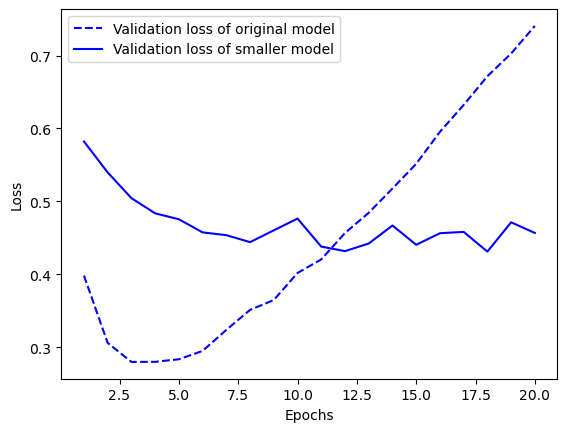

In [36]:
epochs = range(1, 21)
val_loss = history_original.history["val_loss"]
small_val_loss = history_smaller_model.history["val_loss"]
plt.plot(epochs, val_loss, "b--", label="Validation loss of original model")
plt.plot(epochs, small_val_loss, "b-", label="Validation loss of smaller model")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

较小的模型开始过拟合的时间要晚于初始模型，而且开始过拟合之后，它的性能下降速度也更慢。

代码清单 5-12 容量更大的模型

In [20]:
model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(512, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])
history_larger_model = model.fit(
    train_data, train_labels,
    epochs=20, batch_size=512, validation_split=0.4
)

Epoch 1/20
30/30 [==============================] - 2s 56ms/step - loss: 0.6456 - accuracy: 0.6880 - val_loss: 0.4795 - val_accuracy: 0.7700
Epoch 2/20
30/30 [==============================] - 1s 38ms/step - loss: 0.2783 - accuracy: 0.8959 - val_loss: 0.2765 - val_accuracy: 0.8893
Epoch 3/20
30/30 [==============================] - 1s 39ms/step - loss: 0.1494 - accuracy: 0.9426 - val_loss: 0.3228 - val_accuracy: 0.8819
Epoch 4/20
30/30 [==============================] - 1s 39ms/step - loss: 0.0879 - accuracy: 0.9694 - val_loss: 0.2883 - val_accuracy: 0.8893
Epoch 5/20
30/30 [==============================] - 1s 40ms/step - loss: 0.0203 - accuracy: 0.9965 - val_loss: 0.6031 - val_accuracy: 0.8679
Epoch 6/20
30/30 [==============================] - 1s 41ms/step - loss: 0.0997 - accuracy: 0.9835 - val_loss: 0.3906 - val_accuracy: 0.8868
Epoch 7/20
30/30 [==============================] - 1s 41ms/step - loss: 0.0028 - accuracy: 0.9999 - val_loss: 0.5285 - val_accuracy: 0.8883
Epoch 8/20
30

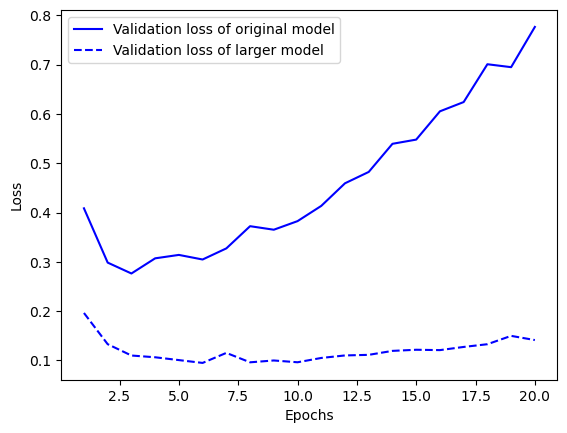

In [ ]:
large_val_loss = history_large_model.history["val_loss"]
plt.plot(epochs, val_loss, "b--", label="Validation loss of original model")
plt.plot(epochs, large_val_loss, "b-", label="Validation loss of larger model")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

仅仅过了一轮，较大模型几乎立即开始过拟合，而且过拟合程度要严重得多。

#### 2. 添加权重正则化

降低过拟合的一种常见方法就是强制让模型权重只能取较小的值，从而限制模型复杂度，这使得权重值的分布更加规则。这种方法叫做**权重正则化**（weight regularization），其实现方法时像模型损失函数中添加与较大权重值相关的**成本**（cost）。这种成本有两种形式：

- **L1 正则化**：添加的成本与**权重系数的绝对值**（权重的 L1 范数）成正比。

- **L2 正则化**：添加的成本与**权重系数的平方**（权重的 L2 范数）成正比，也叫作**权重衰减**（weight decay）

在 Keras 中，添加权重正则化的方法时向层中传入**权重正则化项实例**（weight regularizer instance）作为关键字参数。

代码清单 5-13 向模型中添加 L2 权重正则化

In [29]:
from tensorflow.keras import regularizers

model = keras.Sequential([
    layers.Dense(16,
                 kernel_regularizer=regularizers.l2(0.002),
                 activation="relu"),
    layers.Dense(16,
                 kernel_regularizer=regularizers.l2(0.002),
                 activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])
history_l2_reg = model.fit(
    train_data, train_labels,
    epochs=20, batch_size=512, validation_split=0.4
)

Epoch 1/20
30/30 [==============================] - 2s 57ms/step - loss: 0.6736 - accuracy: 0.6899 - val_loss: 0.4488 - val_accuracy: 0.8771
Epoch 2/20
30/30 [==============================] - 1s 32ms/step - loss: 0.3994 - accuracy: 0.8996 - val_loss: 0.3927 - val_accuracy: 0.8814
Epoch 3/20
30/30 [==============================] - 1s 24ms/step - loss: 0.3276 - accuracy: 0.9196 - val_loss: 0.3676 - val_accuracy: 0.8847
Epoch 4/20
30/30 [==============================] - 1s 26ms/step - loss: 0.2884 - accuracy: 0.9309 - val_loss: 0.3767 - val_accuracy: 0.8793
Epoch 5/20
30/30 [==============================] - 1s 24ms/step - loss: 0.2742 - accuracy: 0.9339 - val_loss: 0.3575 - val_accuracy: 0.8894
Epoch 6/20
30/30 [==============================] - 1s 27ms/step - loss: 0.2575 - accuracy: 0.9435 - val_loss: 0.3659 - val_accuracy: 0.8849
Epoch 7/20
30/30 [==============================] - 1s 26ms/step - loss: 0.2435 - accuracy: 0.9474 - val_loss: 0.4199 - val_accuracy: 0.8627
Epoch 8/20
30

`l2(0.002)` 的含义是该层权重矩阵的每个系数都会使模型总损失值增加 `0.002 * weight_coefficient_value ** 2`

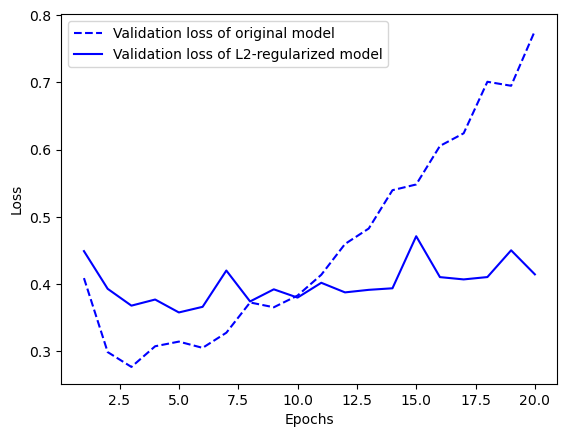

In [31]:
l2_val_loss = history_l2_reg.history["val_loss"]
plt.plot(epochs, val_loss, "b--", label="Validation loss of original model")
plt.plot(epochs, l2_val_loss, "b-", label="Validation loss of L2-regularized model")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

可以看到，两个模型参数相同，但是具有 L2 正则化的模型比初始模型更不容易过拟合。

代码清单 5-14 Keras 中不同的权重正则化项

In [32]:
from tensorflow.keras import regularizers
regularizers.l1(0.001)
regularizers.l1_l2(l1=0.001, l2=0.001)

请注意，权重正则化更常用于较小的深度学习模型。大型深度学习模型往往是过度参数化的，限制权重值大小对模型容量和泛化能力没有太大影响。

#### 3. 添加 dropout

在训练过程中随机**舍弃**该层的一些输出特征（将其设置为 0）。

代码清单 5-15 向 IMDB 模型中添加 dropout

In [37]:
model = keras.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(16, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])
model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])
history_dropout = model.fit(
    train_data, train_labels,
    epochs=20, batch_size=512, validation_split=0.4
)

Epoch 1/20
30/30 [==============================] - 2s 51ms/step - loss: 0.6661 - accuracy: 0.5683 - val_loss: 0.5084 - val_accuracy: 0.8516
Epoch 2/20
30/30 [==============================] - 1s 23ms/step - loss: 0.5362 - accuracy: 0.7379 - val_loss: 0.4092 - val_accuracy: 0.8642
Epoch 3/20
30/30 [==============================] - 1s 24ms/step - loss: 0.4476 - accuracy: 0.8030 - val_loss: 0.3333 - val_accuracy: 0.8816
Epoch 4/20
30/30 [==============================] - 1s 24ms/step - loss: 0.3772 - accuracy: 0.8457 - val_loss: 0.2961 - val_accuracy: 0.8875
Epoch 5/20
30/30 [==============================] - 1s 25ms/step - loss: 0.3329 - accuracy: 0.8752 - val_loss: 0.3054 - val_accuracy: 0.8709
Epoch 6/20
30/30 [==============================] - 1s 25ms/step - loss: 0.2862 - accuracy: 0.8946 - val_loss: 0.2743 - val_accuracy: 0.8913
Epoch 7/20
30/30 [==============================] - 1s 27ms/step - loss: 0.2466 - accuracy: 0.9150 - val_loss: 0.2740 - val_accuracy: 0.8928
Epoch 8/20
30

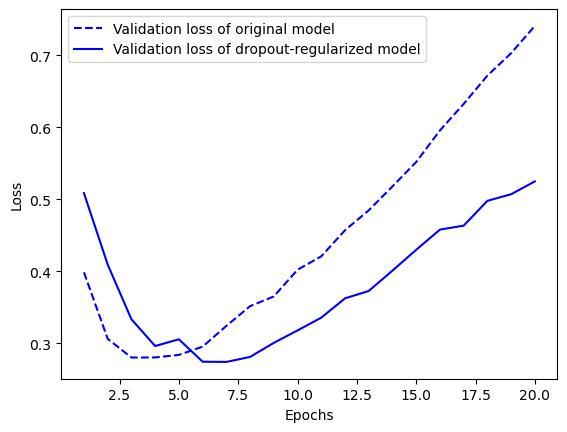

In [39]:
dropout_val_loss = history_dropout.history["val_loss"]
plt.plot(epochs, val_loss, "b--", label="Validation loss of original model")
plt.plot(epochs, dropout_val_loss, "b-", label="Validation loss of dropout-regularized model")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()